In [1]:
import requests
import geopandas as gpd

ERROR 1: PROJ: proj_create_from_database: Open of /project/cper_neon_aop/conda_envs/hls_nrt_ee_env/share/proj failed


In [2]:
baseURL = r"https://us-central1-rap-data-365417.cloudfunctions.net/productionV3"

In [3]:
gdf = gpd.read_file('../data/ground/boundaries/cper_pastures_2017_dissolved.shp')

In [21]:
gdf.total_bounds[2] - gdf.total_bounds[0]

9636.189824573463

In [4]:
bounds = gdf.buffer(100).to_crs(4326).total_bounds
bounds

array([-104.79225636,   40.78221102, -104.67568769,   40.87099069])

In [66]:
import rioxarray

cog_url = (
    "http://rangeland.ntsg.umt.edu/data/rap/rap-vegetation-biomass/v3/"
    "vegetation-biomass-v3-2023.tif"
)
rds = rioxarray.open_rasterio(cog_url, masked=True)
rds

<xarray.DataArray (band: 2, y: 92304, x: 214847)>
[39662474976 values with dtype=float32]
Coordinates:
  * band         (band) int64 1 2
  * x            (x) float64 -124.8 -124.8 -124.8 ... -66.87 -66.87 -66.87
  * y            (y) float64 49.39 49.39 49.39 49.39 ... 24.52 24.52 24.52 24.52
    spatial_ref  int64 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

In [67]:
rds_sub = rds.sel(y=slice(bounds[3], bounds[1]), x=slice(bounds[0], bounds[2]))

In [68]:
display(rds_sub)

<xarray.DataArray (band: 2, y: 330, x: 432)>
[285120 values with dtype=float32]
Coordinates:
  * band         (band) int64 1 2
  * x            (x) float64 -104.8 -104.8 -104.8 ... -104.7 -104.7 -104.7
  * y            (y) float64 40.87 40.87 40.87 40.87 ... 40.78 40.78 40.78 40.78
    spatial_ref  int64 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

In [69]:
rds_sub.rio.crs

CRS.from_epsg(4326)

In [70]:
rds_sub = rds_sub.sum(dim='band')

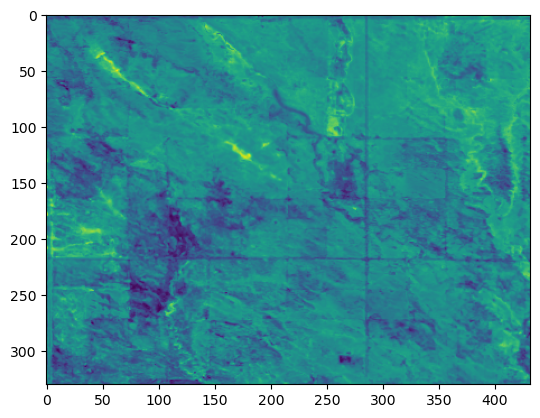

<AxesSubplot:>

In [71]:
from rasterio.plot import show
import numpy as np

In [72]:
ds = rioxarray.open_rasterio('/90daydata/cper_neon_aop/hls_nrt/gcloud/hls_cper_2023_gcloud.nc', mask=True)

In [73]:
bm = ds['Biomass'].isel(date=300)

In [74]:
bm = bm.where(bm != bm.rio.nodata, other=0.0)

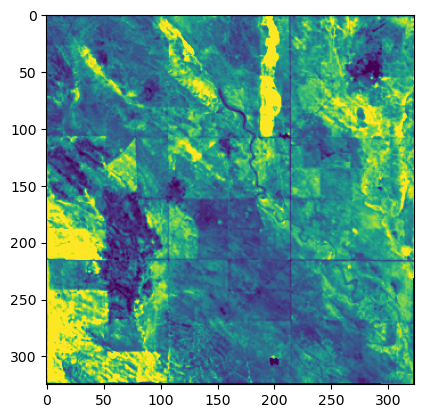

<AxesSubplot:>

In [78]:
show(bm, vmin=200, vmax=2000)

In [76]:
rds_sub_repr = rds_sub.rio.reproject_match(bm)

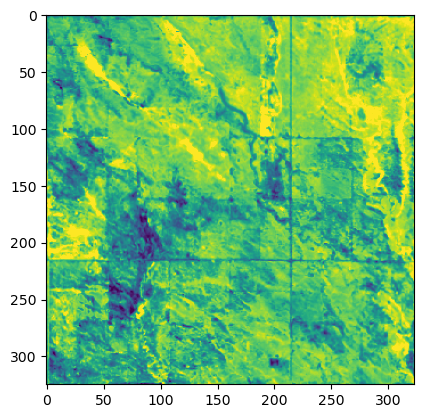

<AxesSubplot:>

In [77]:
show(rds_sub_repr, vmin=200, vmax=2000)

In [79]:
rds_diff = (rds_sub_repr - bm)
rds_diff = rds_diff.where(rds_diff > 0.0, 0.00001)

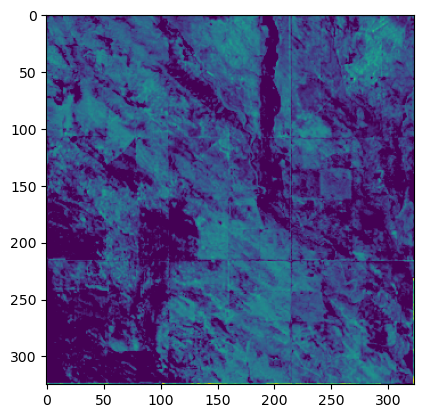

<AxesSubplot:>

In [80]:
show(rds_diff)

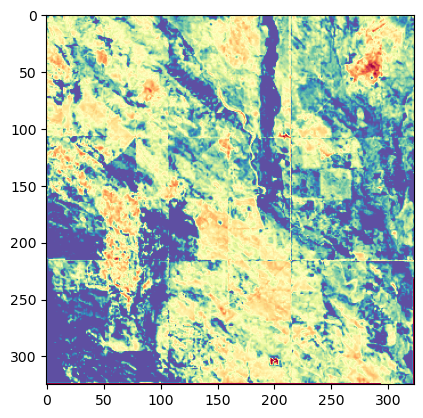

<AxesSubplot:>

In [84]:
show(rds_diff / rds_sub_repr, vmin=0.0, vmax=1.0, cmap='Spectral_r')

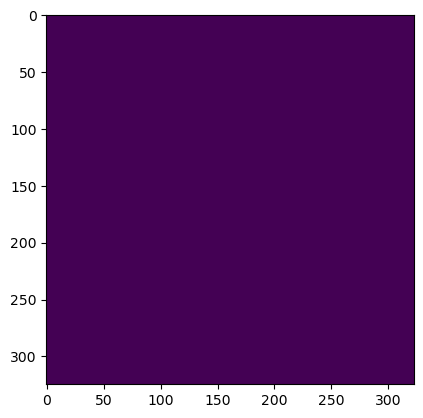

<AxesSubplot:>

In [82]:
show(rds_sub_repr > 0.0)